# Compare Rb $5s \rightarrow np_j$ matrix elements with NIST

This notebook compares the reduced electric-dipole matrix elements
$\langle 5s_{1/2} \Vert d \Vert np_j \rangle$ of rubidium ($n = 5, \dots, 20$ and $j = 1/2, 3/2$)
computed by rydstate with the experimental values of the NIST Atomic Spectra Database (ASD), for

- the **bare** rydberg dipole operator $d(r) = r$, and
- the **dressed** (core-polarization corrected) dipole operator
  $d(r) = r - \frac{\alpha_c}{r^2}\left(1 - e^{-(r/r_c)^3}\right)$.

The later sections then look at how the dressed operator affects the remaining decay channels of the $np$ states
and, finally, the $ns_{1/2}$, $np_{3/2}$ and $nd_{5/2}$ lifetimes.
For those no NIST line strengths are used, so there only the bare and dressed values are compared to each other.

The valence electron polarizes the ionic core; the induced core dipole partially shields the dipole operator.
This correction goes back to [Hameed et al J. Phys. B: Atom. Mol. Phys. 1 822, 1962](https://doi.org/10.1088/0022-3700/1/5/308) and [Weisheit Phys. Rev. A 5, 1621, 1972](https://doi.org/10.1103/PhysRevA.5.1621),
and is also described in [Marinescu et al Phys. Rev. A 49, 982, 1994](https://doi.org/10.1103/PhysRevA.49.982), where the model potential comes from.
The cutoff $r_c$ is fitted to the NIST line strengths.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import rydstate

## NIST reference values

The NIST ASD line strength of an E1 transition is $S = |\langle J \Vert d \Vert J' \rangle|^2$ in atomic units $(e\,a_0)^2$,
so it is directly comparable to the square of rydstate's reduced matrix elements.

In [2]:
# {(n, j): S in (e a0)^2} from https://physics.nist.gov/PhysRefData/ASD/lines_form.html (retrieved 2026-07-24)
nist_s = {
    (5, 0.5): 1.79e1,
    (6, 0.5): 1.11e-1,
    (7, 0.5): 1.32e-2,
    (8, 0.5): 3.31e-3,
    (9, 0.5): 1.28e-3,
    (10, 0.5): 6.24e-4,
    (11, 0.5): 3.79e-4,
    (12, 0.5): 2.02e-4,
    (13, 0.5): 1.28e-4,
    (14, 0.5): 1.04e-4,
    (15, 0.5): 6.85e-5,
    (16, 0.5): 4.82e-5,
    (17, 0.5): 3.75e-5,
    (18, 0.5): 2.83e-5,
    (19, 0.5): 2.34e-5,
    (20, 0.5): 1.50e-5,
    (5, 1.5): 3.58e1,
    (6, 1.5): 2.59e-1,
    (7, 1.5): 3.62e-2,
    (8, 1.5): 1.01e-2,
    (9, 1.5): 4.25e-3,
    (10, 1.5): 2.10e-3,
    (11, 1.5): 1.50e-3,
    (12, 1.5): 8.62e-4,
    (13, 1.5): 5.95e-4,
    (14, 1.5): 4.57e-4,
    (15, 1.5): 2.72e-4,
    (16, 1.5): 2.25e-4,
    (17, 1.5): 1.77e-4,
    (18, 1.5): 1.42e-4,
    (19, 1.5): 1.10e-4,
}

## Bare vs. dressed operator

The dressed operator is used automatically if "electric_dipole" is specified.
To compute the bare values for comparison, one can use "electric_dipole_rydberg" instead.

In [3]:
ground_state = rydstate.RydbergStateSQDTAlkali("Rb", 5, l=0, j=0.5)
basis_np = rydstate.BasisSQDT("Rb", n=(0, 25), l_r=(1, 1), f_tot=(0.5, 1.5))
n_list = np.unique(basis_np.calc_exp_qn("n"))

me_dressed = {
    (state.n, state.calc_exp_qn("j_r")): state.calc_reduced_matrix_element(ground_state, "electric_dipole", unit="e a0")
    for state in basis_np.states
}
me_bare = {
    (state.n, state.calc_exp_qn("j_r")): state.calc_reduced_matrix_element(
        ground_state, "electric_dipole_rydberg", unit="e a0"
    )
    for state in basis_np.states
}

print(f"{'state':>8} {'bare':>10} {'dressed':>10} {'NIST':>8}   (|<5s||d||np_j>| in e a0)")
for n in (5, 6, 10, 15, 20):
    for j in (0.5, 1.5):
        nist = f"{np.sqrt(nist_s[(n, j)]):8.5f}" if (n, j) in nist_s else "     ---"
        print(f"{n:>4}p_{2 * j:1.0f}/2 {abs(me_bare[(n, j)]):10.5f} {abs(me_dressed[(n, j)]):10.5f} {nist}")

   state       bare    dressed     NIST   (|<5s||d||np_j>| in e a0)
   5p_1/2    4.45761    4.24074  4.23084
   5p_3/2    6.28560    5.98559  5.98331
   6p_1/2    0.41666    0.32454  0.33317
   6p_3/2    0.65698    0.52786  0.50892
  10p_1/2    0.04734    0.02358  0.02498
  10p_3/2    0.08238    0.04880  0.04583
  15p_1/2    0.01857    0.00794  0.00828
  15p_3/2    0.03295    0.01790  0.01649
  20p_1/2    0.01072    0.00438  0.00387
  20p_3/2    0.01915    0.01016      ---


## Comparison plot

Left: the matrix elements themselves.
Right: the ratio of the calculated matrix elements to the NIST values.
The color encodes the total angular momentum ($j = 1/2$ blue, $j = 3/2$ orange), and the black-edged crosses the NIST values.
The bare operator overestimates the matrix elements; the dressed operator agrees with the NIST values.

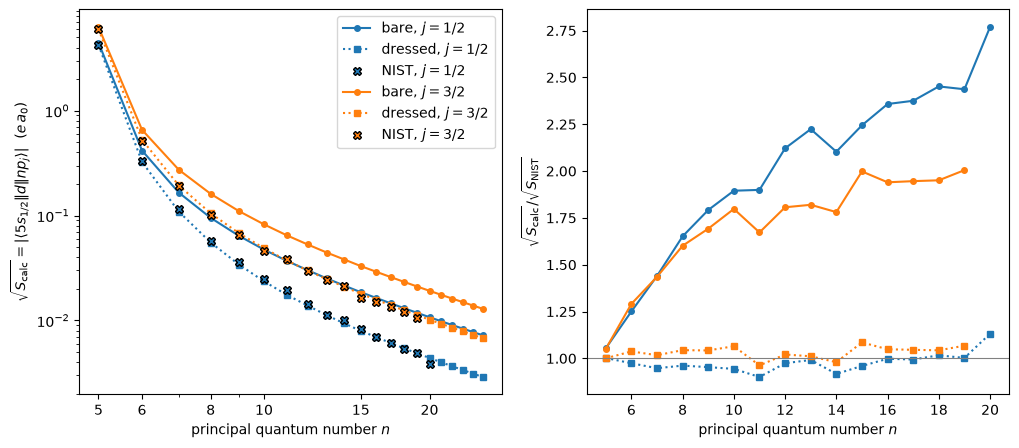

In [4]:
fig, (ax_me, ax_ratio) = plt.subplots(1, 2, figsize=(12, 5))

# the color encodes j, the linestyle and marker encode bare / dressed / NIST
colors = {0.5: "C0", 1.5: "C1"}
operators = {"bare": (me_bare, "-", "o"), "dressed": (me_dressed, ":", "s")}

for j, color in colors.items():
    j_label = f"$j={2 * j:1.0f}/2$"
    n_nist = np.array(sorted(n for (n, jj) in nist_s if jj == j))

    for label, (me, linestyle, marker) in operators.items():
        style = {"color": color, "linestyle": linestyle, "marker": marker, "markersize": 4}
        ax_me.plot(n_list, [abs(me[(n, j)]) for n in n_list], **style, label=f"{label}, {j_label}")
        ax_ratio.plot(n_nist, np.abs([me[(n, j)] / np.sqrt(nist_s[(n, j)]) for n in n_nist]), **style)

    ax_me.plot(
        n_nist,
        [np.sqrt(nist_s[(n, j)]) for n in n_nist],
        color=color,
        linestyle="none",
        marker="X",
        markeredgecolor="black",
        label=f"NIST, {j_label}",
    )

ax_me.set_xscale("log")
ax_me.set_yscale("log")
ax_me.set_xticks([5, 6, 8, 10, 15, 20], labels=["5", "6", "8", "10", "15", "20"])
ax_me.set_xlabel("principal quantum number $n$")
ax_me.set_ylabel(r"$\sqrt{S_\mathrm{calc}} = |\langle 5s_{1/2} \Vert d \Vert np_j \rangle|$  ($e\,a_0$)")
ax_me.legend()

ax_ratio.axhline(1, color="gray", lw=0.8)
ax_ratio.set_xlabel("principal quantum number $n$")
ax_ratio.set_ylabel(r"$\sqrt{S_\mathrm{calc}} / \sqrt{S_\mathrm{NIST}}$")

plt.show()

## Independent check: $5p_j \rightarrow 6d_{j'}$

The cutoff $r_c$ was fitted to the principal series $5s_{1/2} \rightarrow np_j$ only,
so transitions between two *excited* states are an independent test of the dressed operator.
NIST ASD lists three E1 lines connecting the $4p^6\,5p$ and $4p^6\,6d$ configurations.

In [5]:
# {((n, j) lower, (n, j) upper): S in (e a0)^2}
# from https://physics.nist.gov/PhysRefData/ASD/lines_form.html (retrieved 2026-07-28)
nist_s_5p_6d = {
    ((5, 0.5), (6, 1.5)): 1.392,  # 620.63092 nm
    ((5, 1.5), (6, 2.5)): 2.749,  # 629.83252 nm
    ((5, 1.5), (6, 1.5)): 3.11e-1,  # 629.92245 nm
}

print(f"{'transition':>18} {'bare':>10} {'dressed':>10} {'NIST':>10}   (|<5p_j||d||6d_j'>| in e a0)")
for ((n_low, j_low), (n_up, j_up)), line_strength in nist_s_5p_6d.items():
    lower = rydstate.RydbergStateSQDTAlkali("Rb", n_low, l=1, j=j_low)
    upper = rydstate.RydbergStateSQDTAlkali("Rb", n_up, l=2, j=j_up)
    bare = upper.calc_reduced_matrix_element(lower, "electric_dipole_rydberg", unit="e a0")
    dressed = upper.calc_reduced_matrix_element(lower, "electric_dipole", unit="e a0")
    nist = np.sqrt(line_strength)
    transition = f"{n_low}p_{2 * j_low:1.0f}/2 -> {n_up}d_{2 * j_up:1.0f}/2"
    print(
        f"{transition:>18} {abs(bare):10.4f} {abs(dressed):10.4f} {nist:10.4f}"
        f"   (ratios to NIST: {abs(bare) / nist:.3f} / {abs(dressed) / nist:.3f})"
    )

        transition       bare    dressed       NIST   (|<5p_j||d||6d_j'>| in e a0)
  5p_1/2 -> 6d_3/2     1.0322     1.0830     1.1798   (ratios to NIST: 0.875 / 0.918)
  5p_3/2 -> 6d_5/2     1.4684     1.5332     1.6580   (ratios to NIST: 0.886 / 0.925)
  5p_3/2 -> 6d_3/2     0.4920     0.5135     0.5577   (ratios to NIST: 0.882 / 0.921)


Unlike for the principal series, the shielding correction *increases* these matrix elements, by $4-5\%$.
The $-\alpha_c/r^2 (1 - e^{-(r/r_c)^3})$ term contributes only at small $r$ (a few $r_c$), so its sign relative to
the bare integral decides whether it shields or enhances: the $5s \rightarrow np$ integrals are dominated by a
single sign and are shielded, whereas the $5p \rightarrow 6d$ integrals suffer a strong cancellation between an
inner positive and an outer negative lobe, and the small-$r$ correction adds to the surviving remainder --- the
same enhancement already seen for the $np \rightarrow 4d, 5d$ channels above.

The correction moves all three lines towards NIST, but a deficit of $\approx 8\%$ remains.
That deficit is a property of the *reference*, not of the operator: the NIST ASD line strengths for these three
lines are about 10% larger than the high-precision values tabulated by the UD atomic data portal,
far outside the portal's stated uncertainty. Measured against the portal, the dressed operator agrees to
$\approx 1.5\%$ --- see the direct comparison in [compare_udel_portal_matrix_elements.ipynb](compare_udel_portal_matrix_elements.ipynb).

## Why lifetimes barely change: the $np \rightarrow$ low-$n$ $d$ and $s$ channels

The line strengths $S$ to the ground state change by up to a factor $\sim 8$, yet the *lifetimes* of Rydberg $np$ states change only by a few percent.
The reason becomes clear by looking at how the dressed operator affects the other decay channels of an $np_{3/2}$ state: the dominant spontaneous channels go to the low-lying $d$ states,
whose radial integrals have no strong cancellation --- so the shielding correction moves them only mildly.
Below we first plot the bare and dressed matrix elements for the four most important channel families,
and then the ratio of the dressed to the bare line strength for all of them in a single plot.

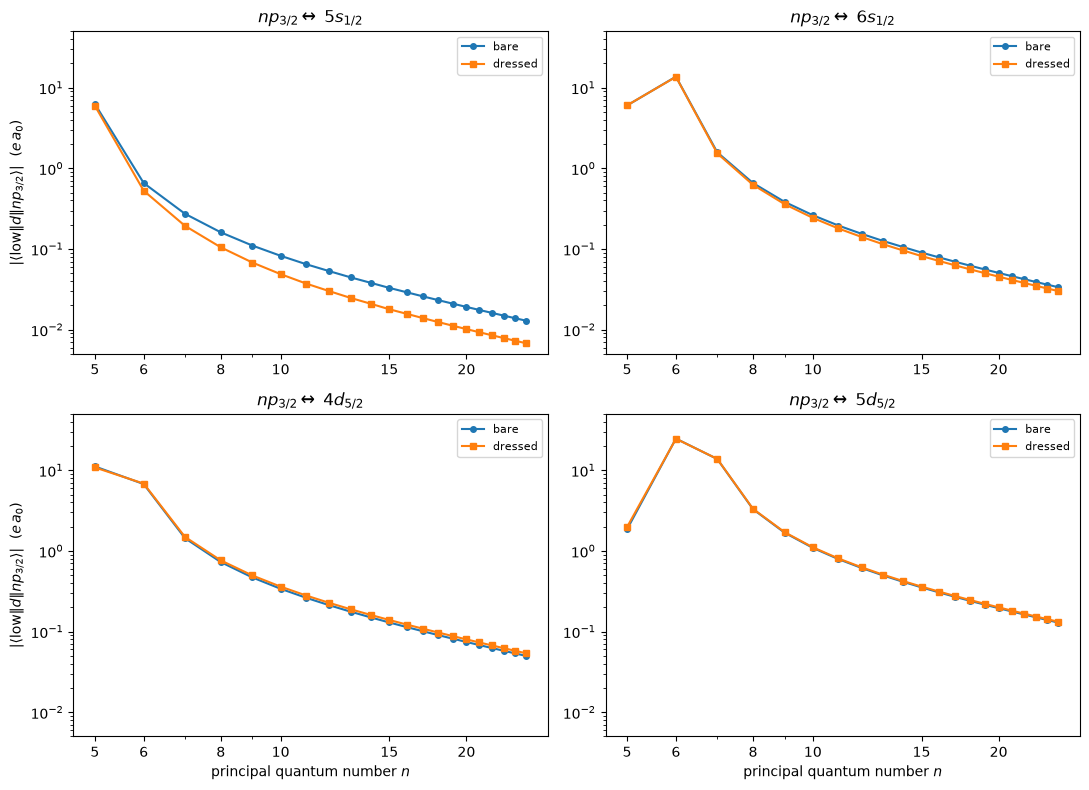

In [6]:
low_n = 5
lower_states = {
    rf"${low_n}s_{{1/2}}$": rydstate.RydbergStateSQDTAlkali("Rb", low_n, l=0, j=0.5),
    rf"${low_n + 1}s_{{1/2}}$": rydstate.RydbergStateSQDTAlkali("Rb", low_n + 1, l=0, j=0.5),
    rf"${low_n - 1}d_{{5/2}}$": rydstate.RydbergStateSQDTAlkali("Rb", low_n - 1, l=2, j=2.5),
    rf"${low_n}d_{{5/2}}$": rydstate.RydbergStateSQDTAlkali("Rb", low_n, l=2, j=2.5),
}
basis_np = rydstate.BasisSQDT("Rb", n=(0, 25), l_r=(1, 1), f_tot=(1.5, 1.5))

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, label in zip(axes.flat, lower_states, strict=True):
    n_list = basis_np.calc_exp_qn("n")
    me_bare_low = basis_np.calc_reduced_matrix_element(lower_states[label], "electric_dipole_rydberg", unit="e a0")
    ax.plot(n_list, np.abs(me_bare_low), "C0o-", markersize=4, label="bare")
    me_dressed_low = basis_np.calc_reduced_matrix_element(lower_states[label], "electric_dipole", unit="e a0")
    ax.plot(n_list, np.abs(me_dressed_low), "C1s-", markersize=4, label="dressed")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(5e-3, 5e1)
    ax.set_xticks([5, 6, 8, 10, 15, 20], labels=["5", "6", "8", "10", "15", "20"])
    ax.set_title(rf"$np_{{3/2}} \leftrightarrow$ {label}")
    ax.legend(fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel("principal quantum number $n$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$|\langle \mathrm{low} \Vert d \Vert np_{3/2} \rangle|$  ($e\,a_0$)")

fig.tight_layout()
plt.show()

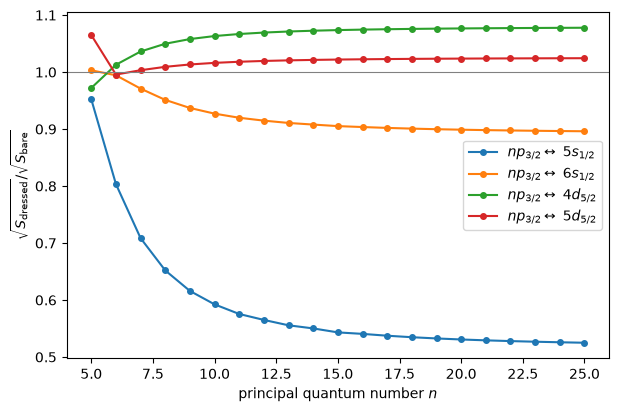

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for i, label in enumerate(lower_states):
    n_list = basis_np.calc_exp_qn("n")
    me_bare_low = basis_np.calc_reduced_matrix_element(lower_states[label], "electric_dipole_rydberg", unit="e a0")
    me_dressed_low = basis_np.calc_reduced_matrix_element(lower_states[label], "electric_dipole", unit="e a0")
    ax.plot(
        n_list,
        np.abs(me_dressed_low / me_bare_low),
        f"C{i}o-",
        markersize=4,
        label=rf"$np_{{3/2}} \leftrightarrow$ {label}",
    )

ax.axhline(1, color="gray", lw=0.8)
ax.set_xlabel("principal quantum number $n$")
ax.set_ylabel(r"$\sqrt{S_\mathrm{dressed}} / \sqrt{S_\mathrm{bare}}$")
ax.legend()

plt.show()

The $np \rightarrow 5s$ line strengths are suppressed down to $\sim$0.3 (and the $np_{1/2}$ ones even further, cf. the plot above),
but this channel carries only a modest share of the total decay rate.
The dominant $np \rightarrow 4d, 5d$ channels move by at most $\sim$15%, partly in the *opposite* direction (the dressed operator enhances these partially-cancelling integrals),
and transitions between neighboring Rydberg states (large $r$, no cancellation) are untouched.
The net effect on the $np_{3/2}$ lifetimes is a few percent --- worked out in detail below.

## Lifetimes vs. principal quantum number

We compute the spontaneous ($T = 0$) lifetimes of the $ns_{1/2}$, $np_{3/2}$ and $nd_{5/2}$ series
with the default (dressed) operator and with the bare operator.

In [8]:
series = {
    "$ns_{1/2}$": rydstate.BasisSQDT("Rb", n=(6, 25), l_r=(0, 0), f_tot=(0.5, 0.5), m=(0.5, 0.5)),
    "$np_{3/2}$": rydstate.BasisSQDT("Rb", n=(0, 25), l_r=(1, 1), f_tot=(1.5, 1.5), m=(0.5, 0.5)),
    "$nd_{5/2}$": rydstate.BasisSQDT("Rb", n=(0, 25), l_r=(2, 2), f_tot=(2.5, 2.5), m=(0.5, 0.5)),
}

lifetimes_dressed = {
    label: [state.get_lifetime(unit="us") for state in basis.states] for label, basis in series.items()
}

element_properties = rydstate.species.rubidium.ElementPropertiesRubidium
alpha_closed_shell_core = element_properties.alpha_closed_shell_core
element_properties.alpha_closed_shell_core = 0  # ignore core polarizability for bare lifetime
rydstate.radial.RadialKet.clear_cached_instances()

lifetimes_bare = {label: [state.get_lifetime(unit="us") for state in basis.states] for label, basis in series.items()}

rydstate.radial.RadialKet.clear_cached_instances()
element_properties.alpha_closed_shell_core = alpha_closed_shell_core  # restore core polarizability

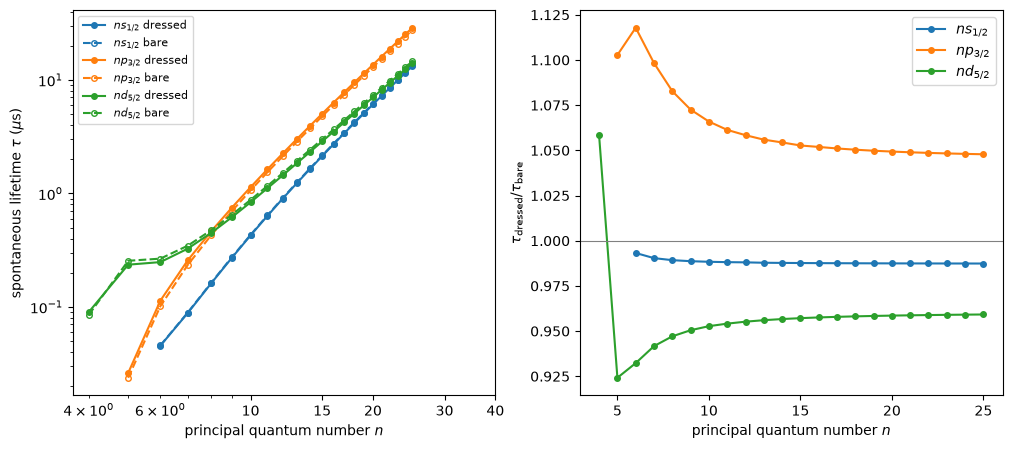

In [9]:
fig, (ax_tau, ax_ratio) = plt.subplots(1, 2, figsize=(12, 5))

for i, (label, basis) in enumerate(series.items()):
    n_list = basis.calc_exp_qn("n")
    ax_tau.plot(n_list, lifetimes_dressed[label], f"C{i}o-", markersize=4, label=f"{label} dressed")
    ax_tau.plot(n_list, lifetimes_bare[label], f"C{i}o--", fillstyle="none", markersize=4, label=f"{label} bare")
    ratio = np.array(lifetimes_dressed[label]) / np.array(lifetimes_bare[label])
    ax_ratio.plot(n_list, ratio, f"C{i}o-", markersize=4, label=label)

ax_tau.set_xscale("log")
ax_tau.set_yscale("log")
ax_tau.set_xticks([10, 15, 20, 30, 40], labels=["10", "15", "20", "30", "40"])
ax_tau.set_xlabel("principal quantum number $n$")
ax_tau.set_ylabel(r"spontaneous lifetime $\tau$ ($\mu$s)")
ax_tau.legend(fontsize=8)

ax_ratio.axhline(1, color="gray", lw=0.8)
ax_ratio.set_xlabel("principal quantum number $n$")
ax_ratio.set_ylabel(r"$\tau_\mathrm{dressed} / \tau_\mathrm{bare}$")
ax_ratio.legend()

plt.show()